# Waveguide bragg gratings

Key paper: https://opg.optica.org/oe/fulltext.cfm?uri=oe-17-17-15330
P. Prabhathan, V. M. Murukeshan, Zhang Jing, and Pamidighantam V. Ramana, "Compact SOI nanowire refractive index sensor using phase shifted Bragg grating," Opt. Express 17, 15330-15341 (2009)
https://doi.org/10.1364/OE.17.015330

Bragg gratings are often used in waveguides, such as optical fibres, which can reflect light of certain frequencies while transmitting others. This is typically achieved by periodically changing the refractive index or dielectric constant in a section of the waveguide, and the reflective and transmitting frequency bands are controlled by appropriately designing the periodicity and material or geometry parameters of the grating.

In this example, sections of two Bragg gratings will be simulated. The first one involves a waveguide with a perfectly aligned corrugation on either side, which causes it to act as a reflector. The second one is similar, but with the corrugation on one side misaligned with the corrugation on the other side, so that the structure primarily transmits power.

Reference:  `Xu Wang, Yun Wang, Jonas Flueckiger, Richard Bojko, Amy Liu, Adam Reid, James Pond, Nicolas A. F. Jaeger, and Lukas Chrostowski, "Precise control of the coupling coefficient through destructive interference in silicon waveguide Bragg gratings," Opt. Lett. 39, 5519-5522 (2014)`, DOI: [10.1364/OL.39.005519](https://doi.org/10.1364/OL.39.005519).

<img src="img/bragg_waveguide.png" width="400" alt="Schematic of the waveguide bragg gratings">

As a relevant example, please see the [distributed Bragg reflector](https://www.flexcompute.com/tidy3d/examples/notebooks/DistributedBraggReflectorCavity/). For more integrated photonic examples such as the [8-Channel mode and polarization de-multiplexer](https://www.flexcompute.com/tidy3d/examples/notebooks/8ChannelDemultiplexer/), the [broadband bi-level taper polarization rotator-splitter](https://www.flexcompute.com/tidy3d/examples/notebooks/BilevelPSR/), and the [broadband directional coupler](https://www.flexcompute.com/tidy3d/examples/notebooks/BroadbandDirectionalCoupler/), please visit our [examples page](https://www.flexcompute.com/tidy3d/examples/). 

If you are new to the finite-difference time-domain (FDTD) method, we highly recommend going through our [FDTD101](https://www.flexcompute.com/fdtd101/) tutorials. 

In [1]:
# ensure compatible versions of matplotlib and ipympl for widget backend

# basic imports
import numpy as np
import matplotlib.pyplot as plt
# Tidy3D imports
import tidy3d as td

## Structure Setup

First, the geometry of the structure is defined. Both waveguides are set up in the same simulation side-by-side.

In [2]:
# materials
n_si3n4 = 1.962735
n_pbs = 1.335
n_sio2 = 1.44834
wavelength0 = 1.31

Air = td.Medium(permittivity=1.0)
Si = td.Medium(permittivity=3.47**2)
si3n4 = td.Medium(permittivity=n_si3n4**2)
pbs = td.Medium(permittivity=n_pbs**2)
SiO2 = td.Medium(permittivity=n_sio2**2)

# geometric parameters
wg_height = 0.4
wg_feed_length = 1.0
wg_feed_width = 0.8
num_periods = 301
period = 0.4167
dc = 0.5

clad_thickness = 5.0
sub_thickness = 2.0

corrug_length = dc*period
wg_length = num_periods * period + 2 * wg_feed_length
wg_width = 0.8 #wg_feed_width - corrug_width
corrug_width = 0.2

freq0 = td.C_0 / wavelength0
fwidth = freq0 / 100.0
run_time = 5.0e-12
wavelength_min = td.C_0 / (freq0 + fwidth)
n2 = 1.656 # for pbs 1.33
n2 = 1.6566 # for pbs 1.335
shift = wavelength0 / (4 * n2)
# shift = 0

# place the two waveguides with their centres half a free-space wavelength apart
# wg1_y = wavelength0 / 2
# wg2_y = -wavelength0 / 2

wg1_y = wg2_y = 0

# waveguide 1
wg1_size = [td.inf, 
            wg_width, 
            wg_height]
wg1_center = [0, 
              0, 
              wg_height / 2]
wg1_medium = si3n4

# corrugation setup for waveguide 1
# cg1_size = [corrug_length, 
#             1, #wg_width + corrug_width, 
#             wg_height]
# cg1_center_plus = [
#     -wg_length / 2 + corrug_length / 2,
#     wg_width / 2 + corrug_width / 2,
#     wg_height / 2,
# ]
# cg1_center_minus = [
#     -wg_length / 2 + corrug_length / 2,
#     -wg_width / 2 - corrug_width / 2 + wg1_y,
#     wg_height / 2,
# ]
# cg1_medium = si3n4

# # corrugation setup for waveguide 2
# cg2_size = [corrug_length, corrug_width, wg_height]
# cg2_center_plus = [
#     -wg_length / 2 + corrug_length / 2,
#     wg_width / 2 + corrug_width / 2 + wg2_y,
#     wg_height / 2,
# ]
# cg2_center_minus = [
#     -wg_length / 2 + corrug_length / 2 + shift,
#     -wg_width / 2 - corrug_width / 2 + wg2_y,
#     wg_height / 2,
# ]
# cg2_medium = si3n4

# Lower and upper cladding
lower_clad = td.Structure(
    geometry=td.Box(center=[0, 0, -clad_thickness / 2], 
                    size=[td.inf, td.inf, clad_thickness]),
    medium=SiO2,
    name="lower_clad",
)
upper_clad = td.Structure(
    geometry=td.Box(center=[0, 0, clad_thickness / 2], 
                    size=[td.inf, td.inf, clad_thickness]),
    medium=pbs,
    name="upper_clad",
)
substrate = td.Structure(
    geometry=td.Box(center=[0, 0, -clad_thickness - sub_thickness / 2], 
                    size=[td.inf, td.inf, sub_thickness]),
    medium=Si,
    name="substrate",
)

# create the first waveguide
waveguide_1 = td.Structure(
    geometry=td.Box(center=wg1_center, size=wg1_size),
    medium=wg1_medium,
    name="waveguide_1",
)

# corrugation on the +y side
center = [-(0.5*dc*period + (1-dc)*period + 0.5*(dc*period+shift)),
          wg1_center[1], 
          wg1_center[2]]

# create the corrugation for the first waveguide
corrug1_plus = []
# print(-wg_length / 2 + period)
for i in range(num_periods//2):
    if i > 0:
        center[0] -= period
    plus = td.Structure(
        geometry=td.Box(center=center, 
                        size=[corrug_length, 
                              wg_width + corrug_width, 
                              wg_height]),
        medium=si3n4,
        name=f"corrug1_plus_{i}",
    )

    corrug1_plus.append(plus)

# Phase shifted Bragg grating
center[0] = 0
plus = td.Structure(
    geometry=td.Box(center=center, 
                    size=[period*dc+shift, 
                          wg_width + corrug_width, 
                          wg_height]),
    medium=si3n4,
    name=f"quarter_phase_shift",
)
corrug1_plus.append(plus)

# corrugation on the +y side
center = [(0.5*dc*period + (1-dc)*period + 0.5*(dc*period+shift)),
          wg1_center[1], 
          wg1_center[2]]

for i in range(num_periods//2):
    if i > 0:
        center[0] += period
    plus = td.Structure(
        geometry=td.Box(center=center, 
                        size=[corrug_length, 
                              wg_width + corrug_width,
                              wg_height]),
        medium=si3n4,
        name=f"corrug1_plus_{i+num_periods//2+1}",
    )

    corrug1_plus.append(plus)
# # create the corrugation for the second waveguide
# corrug2_plus = []
# corrug2_minus = []
# for i in range(num_periods):
#     # corrugation on the +y side
#     center = cg2_center_plus
#     center[0] = -wg_length / 2 + corrug_length / 2 + i * period
#     plus = td.Structure(
#         geometry=td.Box(center=center, size=cg2_size),
#         medium=cg2_medium,
#         name=f"corrug2_plus_{i}",
#     )
#     corrug2_plus.append(plus)
#     # corrugation on the -y side
#     center = cg2_center_minus
#     center[0] = -wg_length / 2 + corrug_length / 2 + i * period
#     minus = td.Structure(
#         geometry=td.Box(center=center, size=cg2_size),
#         medium=cg2_medium,
#         name=f"corrug2_minus_{i}",
#     )
#     corrug2_minus.append(minus)

## Source Setup

A mode source is defined for each waveguide.

In [3]:
# simulation domain and grid
# sim_size = [wg_length + 10 * period, 4, 17]
sim_size = [wg_length + 10 * period, 4, 16]
sim_center = [0, 0, 0]
grid_spec = td.GridSpec.auto(min_steps_per_wvl=20, 
                            wavelength=wavelength0)
boundary_spec = td.BoundarySpec.all_sides(boundary=td.PML())

# mode source for waveguide 1
source1_time = td.GaussianPulse(freq0=freq0, fwidth=fwidth, amplitude=1)
mode_src1 = td.ModeSource(
    center=[-wg_length / 2 - period, wg1_y, wg_height / 2],
    size=[0, waveguide_1.geometry.size[1] * 2, waveguide_1.geometry.size[2] * 2],
    mode_index=0,
    direction="+",
    source_time=source1_time,
    mode_spec=td.ModeSpec(),
)

# # mode source for waveguide 2
# source2_time = td.GaussianPulse(freq0=freq0, fwidth=fwidth, amplitude=1)
# mode_src2 = td.ModeSource(
#     center=[-wg_length / 2 - period, wg2_y, wg_height / 2],
#     size=[0, waveguide_2.geometry.size[1] * 2, waveguide_2.geometry.size[2] * 2],
#     mode_index=0,
#     direction="+",
#     source_time=source2_time,
#     mode_spec=td.ModeSpec(),
# )

## Monitor Setup

To visualize the field distribution in the waveguides, a monitor is placed in the `xy` plane cutting through both waveguides. A pair of flux monitors is also placed on the far side the demonstrate the transmission and reflection characteristics.

In [4]:
%matplotlib widget
# create monitors
monitor_xy = td.FieldMonitor(
    center=[0, 0, wg_height / 2],
    size=[wg_length, 2 * wavelength0 + wg_width + 2 * corrug_width, 0],
    freqs=[freq0],
    name="fields_xy",
)

freqs = np.linspace(freq0 - 2 * fwidth, freq0 + 2 * fwidth, 200)
monitor_flux_aligned = td.FluxMonitor(
    center=[wg_length / 2 + period, wg1_y, wg_height / 2],
    size=[0, waveguide_1.geometry.size[1] * 3, waveguide_1.geometry.size[2] * 5],
    freqs=freqs,
    name="flux_aligned",
)

# monitor_flux_misaligned = td.FluxMonitor(
#     center=[wg_length / 2 + period, wg2_y, wg_height / 2],
#     size=[0, waveguide_2.geometry.size[1] * 3, waveguide_2.geometry.size[2] * 5],
#     freqs=freqs,
#     name="flux_misaligned",
# )


## Create Simulation

All the structures, sources, and monitors are consolidated, and the simulation is created and visualized.

0.4060440721960642


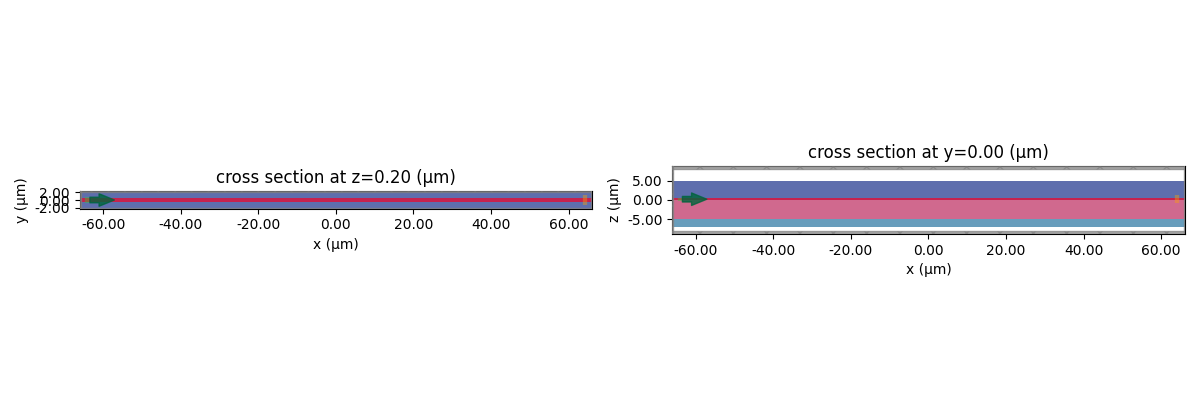

In [5]:
# list of all structures
structures = (
    [substrate, lower_clad, upper_clad, waveguide_1]
    + corrug1_plus
    # + corrug1_minus
    # + corrug2_plus
    # + corrug2_minus
)
print(dc*period+shift)
# list of all sources
# sources = [mode_src1, mode_src2]
sources = [mode_src1]  # single source
# list of all monitors
# monitors = [monitor_xy, monitor_flux_aligned, monitor_flux_misaligned]
monitors = [ monitor_flux_aligned, ]

# create the simulation
sim = td.Simulation(
    center=sim_center,
    size=sim_size,
    grid_spec=grid_spec,
    structures=structures,
    sources=sources,
    monitors=monitors,
    run_time=run_time,
    boundary_spec=boundary_spec,
)

# visualize simulation setup
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
sim.plot(z=wg_height / 2, ax=ax1)
sim.plot(y=0, ax=ax2)
plt.tight_layout()
plt.show()


## Run Simulation

In [6]:
# run simulation
import tidy3d.web as web

sim_data = web.run(sim, task_name="bragg", path="data/bragg.hdf5", verbose=True)

18:04:02 Eastern Standard Time Created task 'bragg' with task_id                
                               'fdve-e05dc785-1768-4332-8744-f9e5ad78d51f' and  
                               task_type 'FDTD'.

                               View task using web UI at                        
                               ]8;id=196803;https://tidy3d.simulation.cloud/workbench?taskId=fdve-e05dc785-1768-4332-8744-f9e5ad78d51f\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=475350;https://tidy3d.simulation.cloud/workbench?taskId=fdve-e05dc785-1768-4332-8744-f9e5ad78d51f\taskId]8;;\
                               ]8;id=196803;https://tidy3d.simulation.cloud/workbench?taskId=fdve-e05dc785-1768-4332-8744-f9e5ad78d51f\=]8;;\]8;id=823137;https://tidy3d.simulation.cloud/workbench?taskId=fdve-e05dc785-1768-4332-8744-f9e5ad78d51f\fdve]8;;\]8;id=196803;https://tidy3d.simulation.cloud/workbench?taskId=fdve-e05dc785-1768-4332-8744-f9e5ad78d51f\-e05dc785-1768-4332-8744-f9e5ad78d51f']8;;\.

                               Task folder: ]8;id=868876;https://tidy3d.simulation.cloud/folders/8993e9fd-16eb-42bd-a54a-7270ad3d7232\'default']8;;\.

Output()

18:04:08 Eastern Standard Time Maximum FlexCredit cost: 24.668. Minimum cost    
                               depends on task execution details. Use           
                               'web.real_cost(task_id)' to get the billed       
                               FlexCredit cost after a simulation run.

18:04:09 Eastern Standard Time status = success

Output()

18:04:11 Eastern Standard Time loading simulation from data/bragg.hdf5

18:04:17 Eastern Standard Time WARNING: Simulation final field decay value of   
                               0.00866 is greater than the simulation shutoff   
                               threshold of 1e-05. Consider running the         
                               simulation again with a larger 'run_time'        
                               duration for more accurate results.              

## Field Plot

The frequency-domain fields are plotted in the `xy` plane cutting through the waveguides. We notice that the grating with aligned corrugation effectively reflects power at the design frequency, while the misalignment in the second grating causes it to be mostly transmissive.

In [7]:
# # plot fields on the monitor
# fig, ax = plt.subplots(2, 1, tight_layout=True, figsize=(9, 5))
# sim_data.plot_field(field_monitor_name="fields_xy", field_name="Ey", val="real", f=freq0, ax=ax[0])
# sim_data.plot_field(field_monitor_name="fields_xy", field_name="Sx", val="real", f=freq0, ax=ax[1])
# plt.show()


## Transmission and Reflection

The observations made in the field plot above can be confirmed by plotting the flux recorded by the flux monitors as a function of frequency. In the region of the design frequency, indicated by the dashed black line, the drop in flux for the aligned-corrugation grating confirms its reflective property. 

ValueError: dimensions ('f',) must have the same length as the number of data dimensions, ndim=0

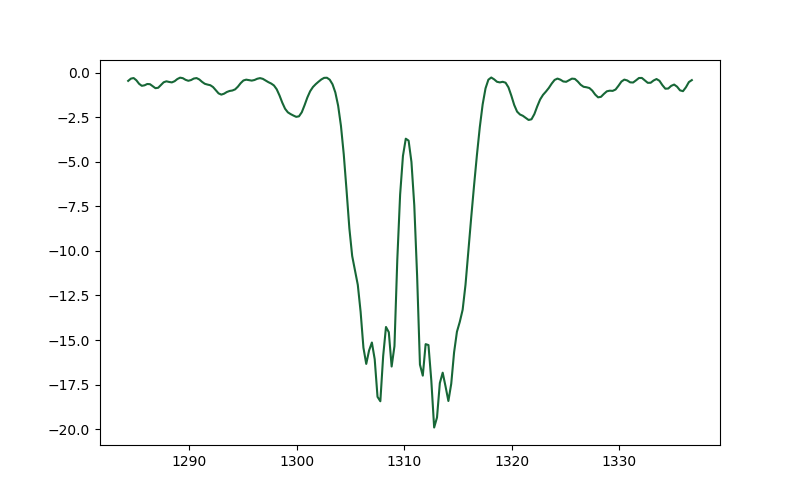

In [8]:
%matplotlib widget

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(td.C_0*1e3 / freqs, 10*np.log10(sim_data["flux_aligned"].flux))
# ax.plot(td.C_0 / freqs, sim_data["flux_misaligned"].flux, label="Misaligned corrugation")

# vertical line at design frequency
# ax.axvline(td.C_0 / freq0, ls="--", color="k")
# find peak wavelength and annotate
flux = sim_data["flux_aligned"].flux
idx_peak = np.argmax(flux)
lambda_um = td.C_0 / freqs[idx_peak]
lambda_nm = lambda_um * 1e3
x_peak = ax.lines[0].get_xdata()[idx_peak]
y_peak = 10 * np.log10(flux[idx_peak])

ax.axvline(x_peak, color='r', ls='--', label=f'Peak {lambda_nm:.1f} nm')
ax.annotate(f'{lambda_nm:.1f} nm', xy=(x_peak, y_peak),
            xytext=(10, 10), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='r'),
            fontsize=9)

ax.set(xlabel="Wavelength (µm)", ylabel="Transmission")

ax.grid(True)
plt.legend()
plt.show()
